In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('C:/.vscode/jupiter/main/W0/data/togo-dapaong_qc.csv')
sns.set(style="whitegrid", rc={"figure.figsize": (10,5)})

In [3]:
data.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


In [4]:
data.shape

(525600, 19)

In [5]:
# Summary Statistics 
data.describe() 

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN


In [6]:
# list any column with > 5% nulls.
data.isna().sum() 

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  str    
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB          525600 non-null  float64


In [8]:
data[['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']].describe()

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000
mean,230.555040,151.258469,116.444352,226.144375,219.568588,2.368093,3.229490
std,322.532347,250.956962,156.520714,317.346938,307.932510,1.462668,1.882565
min,-12.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,1.400000,1.900000
50%,2.100000,0.000000,2.500000,4.400000,4.300000,2.200000,2.900000
75%,442.400000,246.400000,215.700000,422.525000,411.000000,3.200000,4.400000
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,16.100000,23.100000


In [9]:
data.dtypes

Timestamp            str
GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object

In [10]:
clean_data = data.copy()
clean_data = clean_data.dropna()


In [11]:
display(data.describe(include='all'))

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
unique,525600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2021-10-25 00:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,NaN,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,NaN,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,NaN,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,NaN,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,NaN,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN


In [12]:
missing = data.isna().sum()
missing_pct = 100 * missing / len(data)
print(missing_pct)

Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64


In [13]:
# adapt column name if different
ts_col = 'Timestamp'
data[ts_col] = pd.to_datetime(data[ts_col], errors='coerce')
data = data.sort_values(ts_col)
data.set_index(ts_col, inplace=True) 

In [14]:
data.head()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


In [15]:
data.dtypes

GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object

In [16]:
data.head()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


In [17]:
data.keys()

Index(['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust',
       'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA',
       'TModB', 'Comments'],
      dtype='str')

In [18]:
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS','WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB']
data[key_cols].describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000


In [19]:
data.isna().sum()/len(data)*100

GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64

In [20]:
key_cols = ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']
zs = np.abs(stats.zscore(data[key_cols].dropna()))  # drops rows with NA in these cols for z-score calc

# create boolean Series aligned to data (will be shorter if dropna used); better approach below:
# zscore_data = data[key_cols].apply(lambda x: (x - x.mean())/x.std())

outlier_mask = (zs > 3).any(axis=1)
data['is_outlier'] = outlier_mask
data['n_outlier_cols'] = (zs <= 3).sum(axis=1)
outlier_count = data['is_outlier'].sum()
outlier_count, f"{outlier_count/len(data):.2%} of rows flagged as outliers" 

(np.int64(9251), '1.76% of rows flagged as outliers')

In [21]:
print(data[['is_outlier', 'n_outlier_cols']][data["is_outlier"]==True].head())

                     is_outlier  n_outlier_cols
Timestamp                                      
2021-10-28 11:06:00        True               6
2021-10-28 18:11:00        True               6
2021-10-28 18:12:00        True               5
2021-10-28 18:14:00        True               5
2021-10-28 18:21:00        True               6


In [22]:
data[data["is_outlier"] == True].count()

GHI               9251
DNI               9251
DHI               9251
ModA              9251
ModB              9251
Tamb              9251
RH                9251
WS                9251
WSgust            9251
WSstdev           9251
WD                9251
WDstdev           9251
BP                9251
Cleaning          9251
Precipitation     9251
TModA             9251
TModB             9251
Comments             0
is_outlier        9251
n_outlier_cols    9251
dtype: int64

In [23]:
clean = data.copy()

# Option A: median-impute key columns
for c in key_cols:
    if c in clean.columns:
        clean[c] = clean[c].fillna(clean[c].median())

# Option B (optional): drop rows where essential irradiance missing
# clean = clean.dropna(subset=['GHI','DNI','DHI'])

# Remove extreme outlier rows if you choose
clean = clean[~clean['is_outlier']]

# quick check
clean[key_cols].describe()

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
count,516349.000000,516349.000000,516349.000000,516349.000000,516349.000000,516349.000000,516349.000000
mean,223.859675,147.975931,112.781249,219.380751,213.028150,2.312185,3.154247
std,317.306277,247.683690,151.571744,311.854841,302.625802,1.377997,1.762192
min,-12.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,1.400000,1.900000
50%,0.500000,0.000000,1.500000,2.800000,2.800000,2.200000,2.900000
75%,423.200000,237.900000,211.600000,404.100000,393.100000,3.200000,4.100000
max,1198.000000,904.100000,586.000000,1171.200000,1143.000000,6.700000,8.800000


In [24]:
data.columns

Index(['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust',
       'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA',
       'TModB', 'Comments', 'is_outlier', 'n_outlier_cols'],
      dtype='str')

In [25]:
clean.reset_index().to_csv('../data/togo_clean.csv', index=False)

In [26]:
clean.head()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,is_outlier,n_outlier_cols
Timestamp,,,,,,,,,,,,,,,,,,,,
2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN,False,7
2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN,False,7
2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN,False,7
2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN,False,7
2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN,False,7


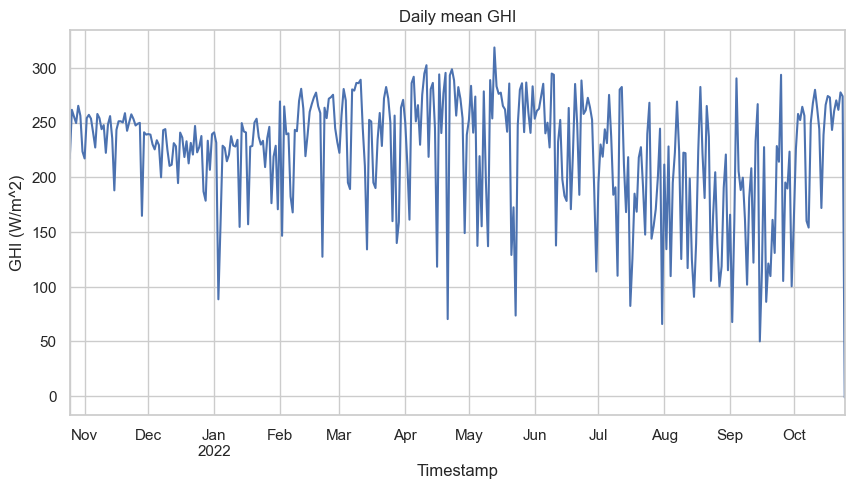

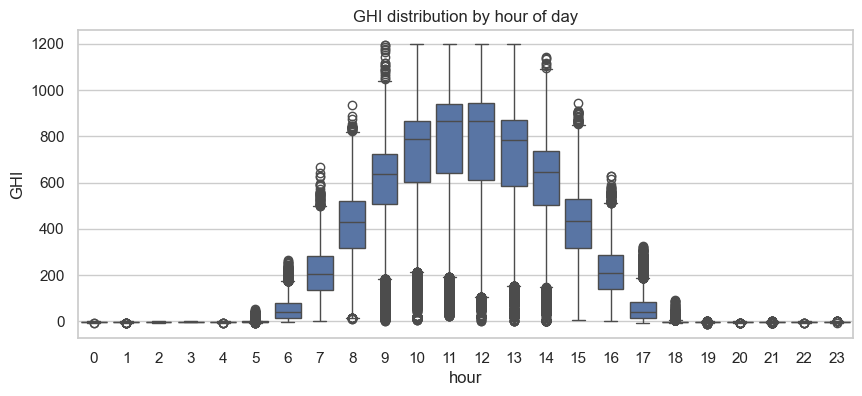

In [27]:
# daily mean
daily = clean.resample('D').mean()

plt.figure()
daily['GHI'].plot(title='Daily mean GHI')
plt.ylabel('GHI (W/m^2)')
plt.show()

# monthly pattern (boxplot by hour of day or month)
clean['hour'] = clean.index.hour
plt.figure(figsize=(10,4))
sns.boxplot(x='hour', y='GHI', data=clean.reset_index())
plt.title('GHI distribution by hour of day')
plt.show()



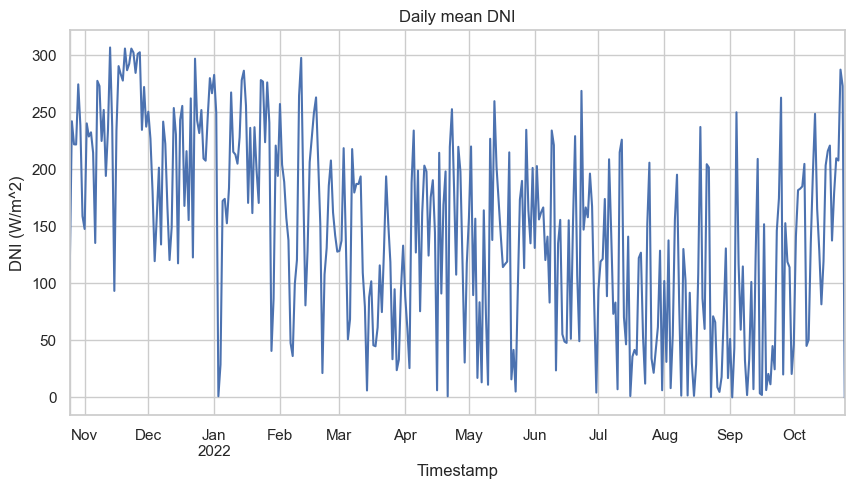

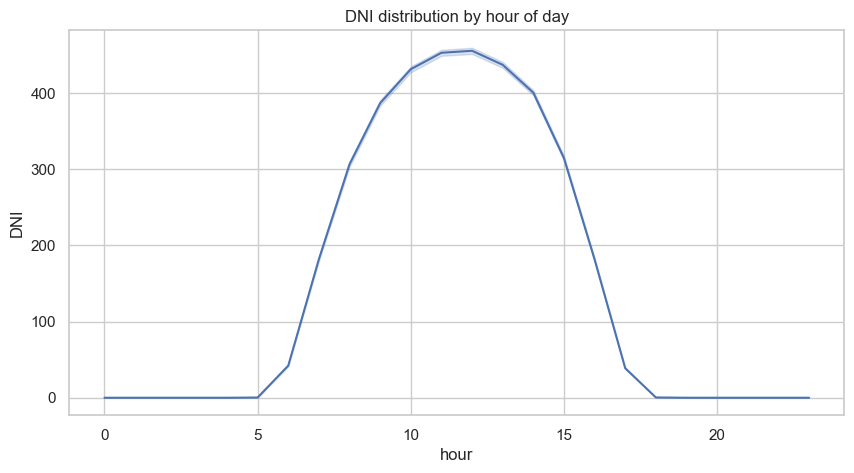

In [28]:
plt.figure()
daily["DNI"].plot(title='Daily mean DNI')
plt.ylabel('DNI (W/m^2)')
plt.show()

plt.figure()
sns.lineplot(x='hour', y='DNI', data=clean.reset_index())
plt.title('DNI distribution by hour of day')
# daily["DNI"].plot(title='Daily mean DNI')
# plt.ylabel('DNI (W/m^2)')
plt.show()


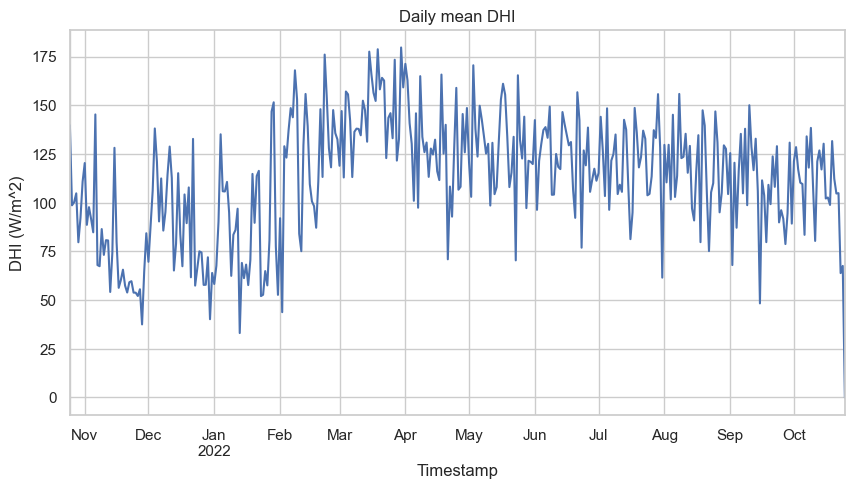

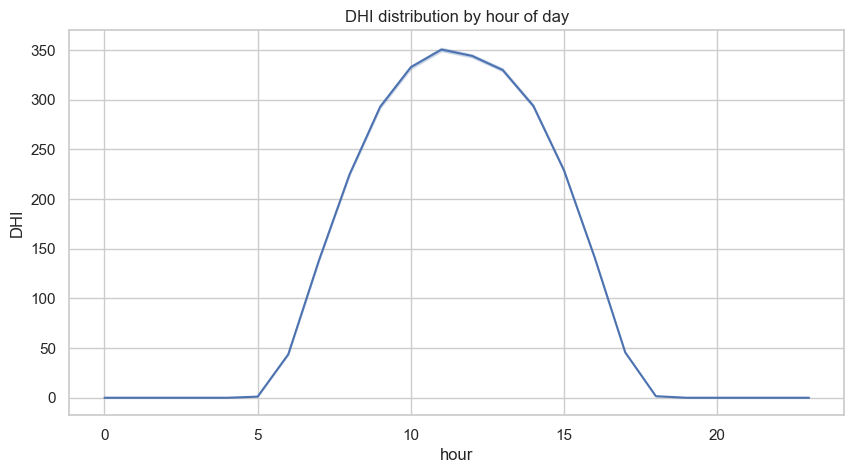

In [29]:
plt.figure()
daily["DHI"].plot(title='Daily mean DHI')
plt.ylabel('DHI (W/m^2)')
plt.show()

plt.figure()
sns.lineplot(x='hour', y='DHI', data=clean.reset_index())
plt.title('DHI distribution by hour of day')
# daily["DHI"].plot(title='Daily mean DHI')
# plt.ylabel('DHI (W/m^2)')
plt.show()

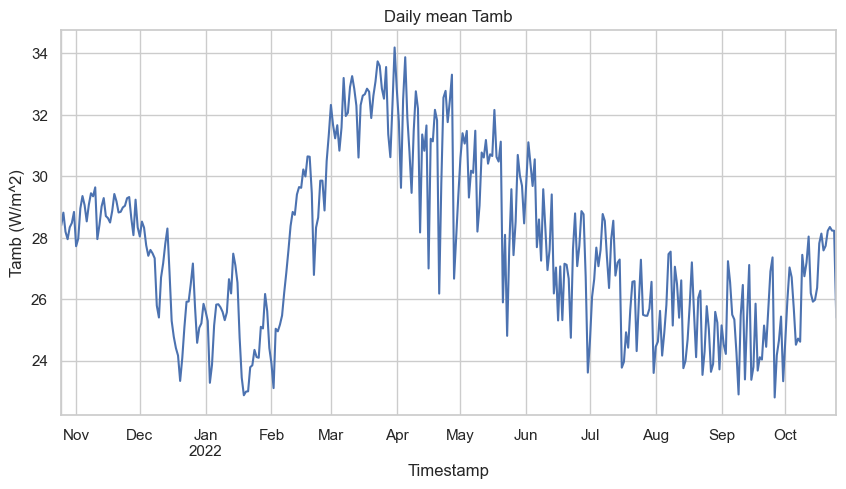

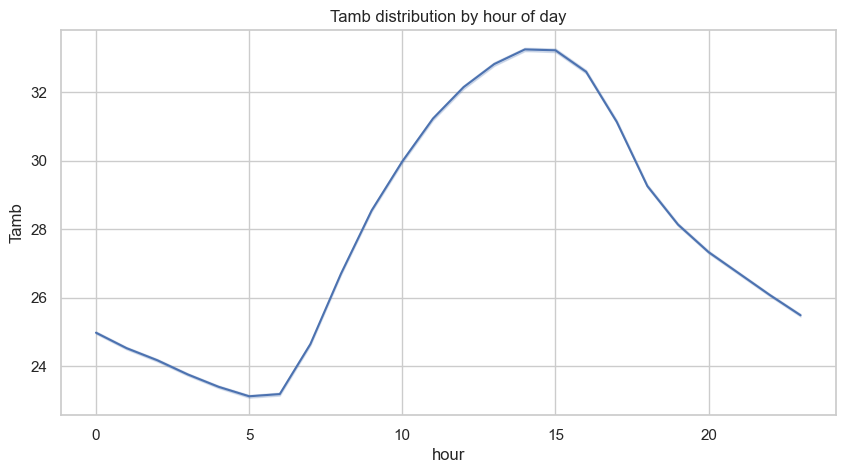

In [30]:
plt.figure()
daily["Tamb"].plot(title='Daily mean Tamb')
plt.ylabel('Tamb (W/m^2)')
plt.show()

plt.figure()
sns.lineplot(x='hour', y='Tamb', data=clean.reset_index())
plt.title('Tamb distribution by hour of day')
# daily["Tamb"].plot(title='Daily mean Tamb')
# plt.ylabel('Tamb (W/m^2)')
plt.show()

In [31]:
# print(daily.columns)

# plt.figure()
# daily['GHI'].plot(title='Daily mean GHI')
# # plt.show()
# daily['DNI'].plot(title='Daily mean DNI')
# daily['GHI'].plot(title='Daily mean GHI')
# daily['DHI'].plot(title='Daily mean DHI')
# plt.ylabel('GHI (W/m^2)')
clean.head()
# sns.barplot(x='hour', y='GHI', data=clean.reset_index())
# sns.histplot(data=clean, x='GHI', bins=50, kde=True)
# sns.violinplot(x='hour', y='GHI', data=clean.reset_index())
# clean["WD"]

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,...,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,is_outlier,n_outlier_cols,hour
Timestamp,,,,,,,,,,,,,,,,,,,,,
2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,...,1.1,977,0,0.0,24.7,24.4,NaN,False,7,0
2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,...,0.7,977,0,0.0,24.7,24.4,NaN,False,7,0
2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,...,2.9,977,0,0.0,24.7,24.4,NaN,False,7,0
2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,...,4.6,977,0,0.0,24.7,24.4,NaN,False,7,0
2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,...,1.6,977,0,0.0,24.7,24.4,NaN,False,7,0


In [32]:
data.head()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,is_outlier,n_outlier_cols
Timestamp,,,,,,,,,,,,,,,,,,,,
2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN,False,7
2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN,False,7
2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN,False,7
2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN,False,7
2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN,False,7


,ModA,ModB
Cleaning,,
0,219.217037,212.861920
1,528.864835,527.268498


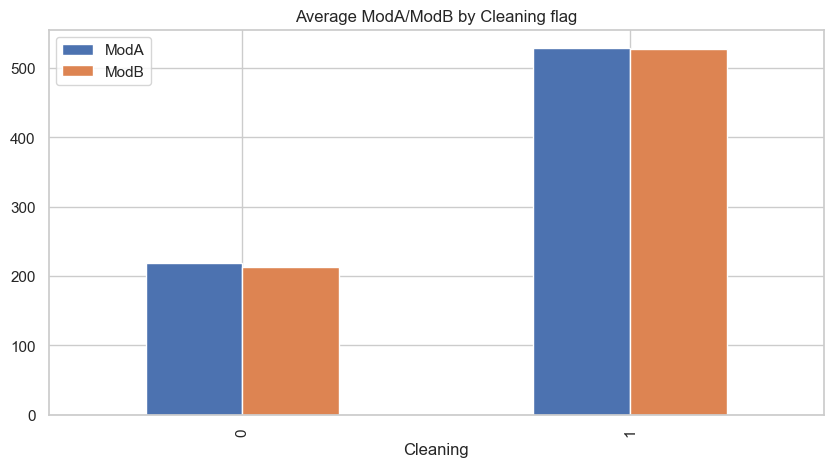

In [33]:
if 'Cleaning' in clean.columns:
    grp = clean.reset_index().groupby('Cleaning')[['ModA','ModB']].mean()
    display(grp)
    grp.plot(kind='bar', title='Average ModA/ModB by Cleaning flag')
    plt.show()

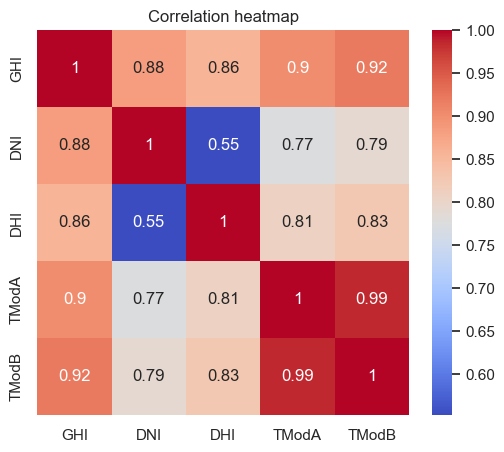

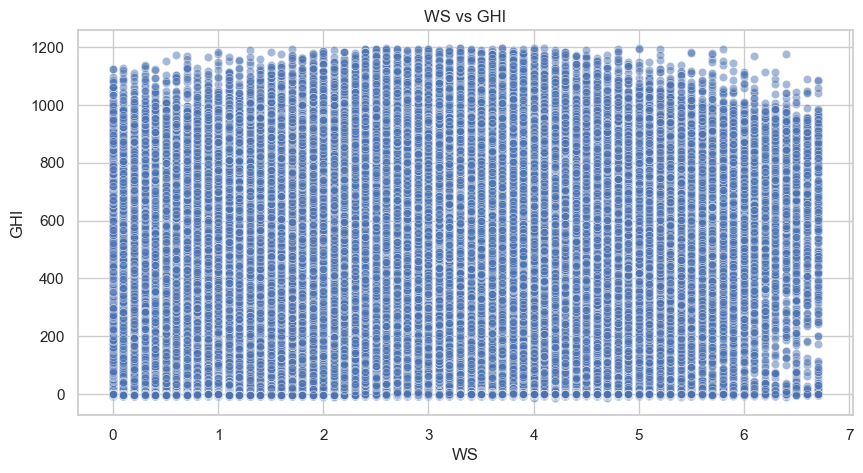

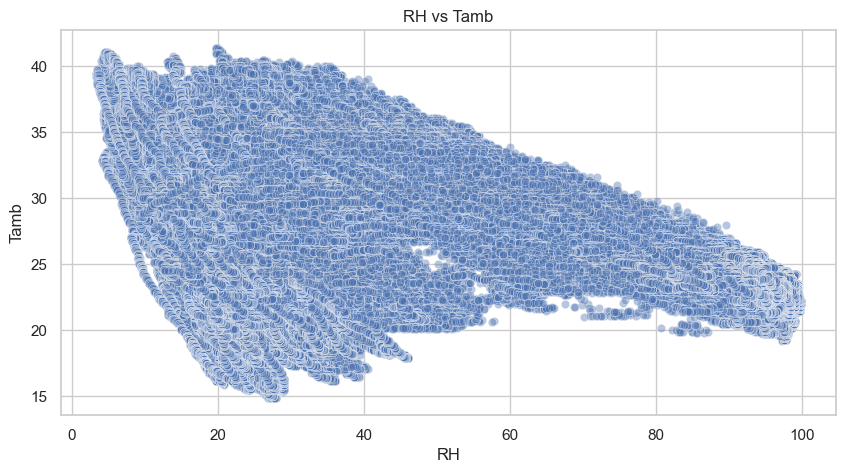

In [34]:
corr_cols = ['GHI','DNI','DHI','TModA','TModB'] 
plt.figure(figsize=(6,5))
sns.heatmap(clean[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

# scatter examples
sns.scatterplot(x='WS', y='GHI', data=clean, alpha=0.5)
plt.title('WS vs GHI')
plt.show()

sns.scatterplot(x='RH', y='Tamb', data=clean, alpha=0.4)
plt.title('RH vs Tamb')
plt.show()

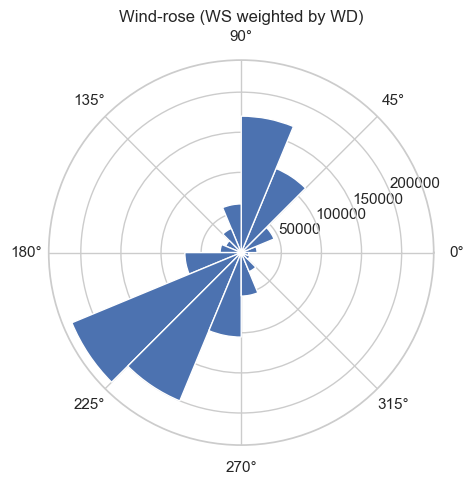

In [40]:
# Wind-rose style plot (simple polar histogram)

if 'WD' in clean.columns and 'WS' in clean.columns:
    wd = np.deg2rad(clean['WD'].dropna())
    ws = clean.loc[wd.index, 'WS'].fillna(0)
    bins = 16
    angles = np.linspace(0, 2*np.pi, bins+1)
    counts, _ = np.histogram(wd, bins=angles, weights=ws)
    angles_mid = (angles[:-1] + angles[1:]) / 2

    ax = plt.subplot(111, polar=True)
    ax.bar(angles_mid, counts, width=(2*np.pi/bins), bottom=0.0)
    ax.set_title('Wind-rose (WS weighted by WD)')
    plt.show()  
# print(wd)

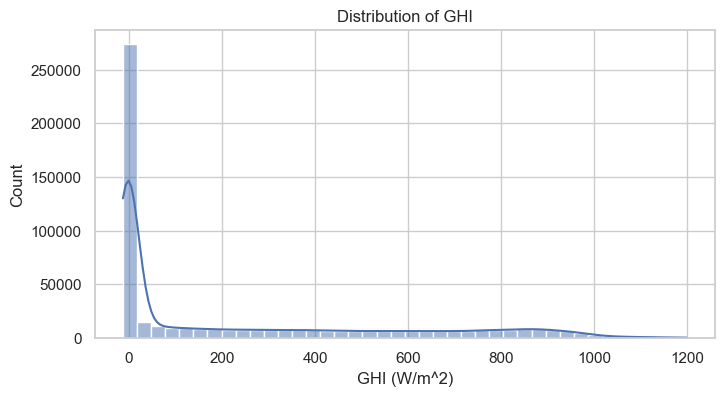

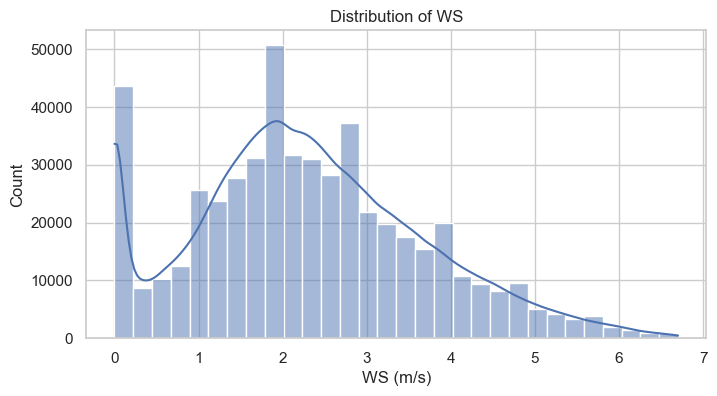

In [36]:
plt.figure(figsize=(8,4))
sns.histplot(clean['GHI'].dropna(), bins=40, kde=True)
plt.title('Distribution of GHI')
plt.xlabel('GHI (W/m^2)')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(clean['WS'].dropna(), bins=30, kde=True)
plt.title('Distribution of WS')
plt.xlabel('WS (m/s)')
plt.show()

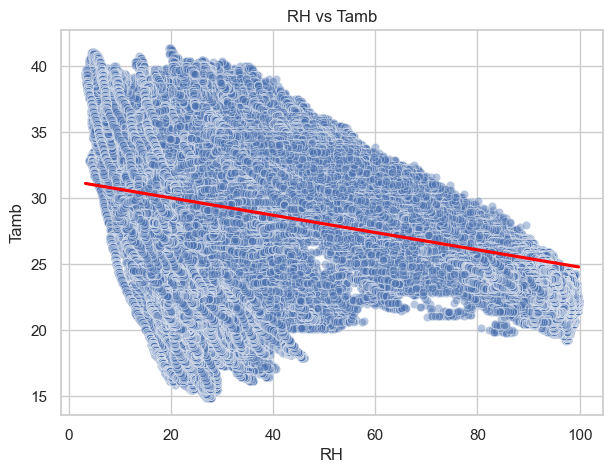

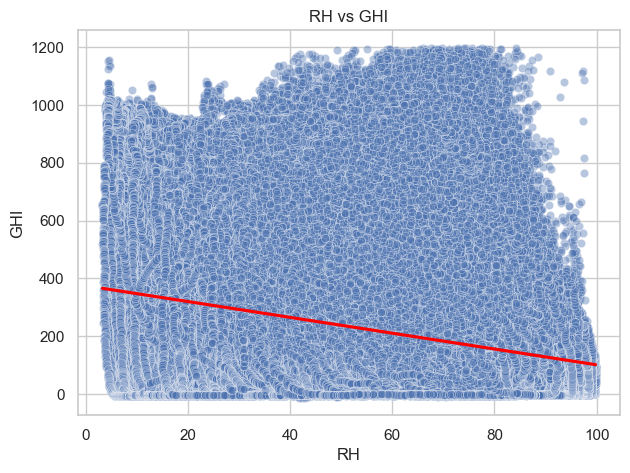

corr(RH, Tamb) = -0.39505049892379557
corr(RH, GHI)  = -0.2475986974094972


In [37]:

## 2) Temperature Analysis (`RH` influence on `Tamb` and solar radiation)
# This checks if humidity is related to temperature and solar output.


# RH vs Tamb
plt.figure(figsize=(7,5))
sns.scatterplot(data=clean, x='RH', y='Tamb', alpha=0.4)
sns.regplot(data=clean, x='RH', y='Tamb', scatter=False, color='red')
plt.title('RH vs Tamb')
plt.show()

# RH vs GHI
plt.figure(figsize=(7,5))
sns.scatterplot(data=clean, x='RH', y='GHI', alpha=0.4)
sns.regplot(data=clean, x='RH', y='GHI', scatter=False, color='red')
plt.title('RH vs GHI')
plt.show()

# quick numeric check
print("corr(RH, Tamb) =", clean[['RH','Tamb']].corr().iloc[0,1])
print("corr(RH, GHI)  =", clean[['RH','GHI']].corr().iloc[0,1])


# How to interpret correlation:
# - near `+1`: strong positive relation
# - near `-1`: strong negative relation
# - near `0`: weak/no linear relation



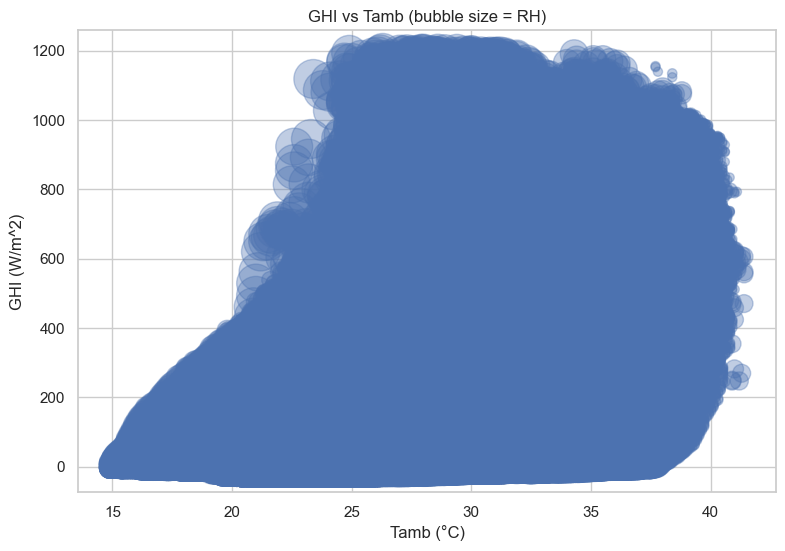

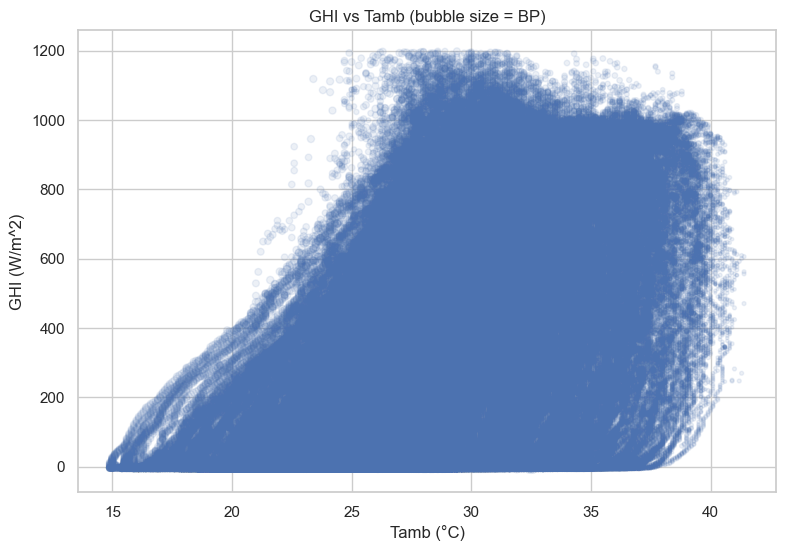

In [41]:


## 3) Bubble Chart (`GHI` vs `Tamb`, bubble size = `RH` or `BP`)
# This combines 3 variables in one figure.


plt.figure(figsize=(9,6))
sizes = (clean['RH'].fillna(0).clip(0,100) + 1) * 8   # bubble size from RH
plt.scatter(clean['Tamb'], clean['GHI'], s=sizes, alpha=0.35)
plt.xlabel('Tamb (°C)')
plt.ylabel('GHI (W/m^2)')
plt.title('GHI vs Tamb (bubble size = RH)')
plt.show()


# If you want bubble size by pressure instead:

sizes_bp = (clean['BP'].fillna(clean['BP'].median()) - clean['BP'].min() + 1) * 2
plt.figure(figsize=(9,6))
plt.scatter(clean['Tamb'], clean['GHI'], s=sizes_bp, alpha=0.1)
plt.xlabel('Tamb (°C)')
plt.ylabel('GHI (W/m^2)')
plt.title('GHI vs Tamb (bubble size = BP)')
plt.show()

